上游代码 -> "ControlMultipointsBroyden.py", "ControlMultipoints.py"

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [31]:
directory = "."
pattern = re.compile(r'loss_list_ada_(\d+)\.csv')

results = []
ada_dict = {}

# 遍历指定目录下的所有文件和文件夹
for filename in os.listdir(directory):
    # 检查当前项是否是文件
    if os.path.isfile(os.path.join(directory, filename)):
        # 对文件名进行正则匹配
        match = pattern.match(filename)
        
        # 如果匹配成功
        if match:
            # 提取第一个捕获组的内容（即整数部分），并转换为int类型
            integer_value = int(match.group(1))
            results.append({'filename': filename, 'integer': integer_value})
            loss_np = np.loadtxt(filename, delimiter=',')
            ada_dict[integer_value] = loss_np

In [32]:
# Dictionary to store the earliest time step where loss < 1.e-6 for each key
convergence_steps = {}

for key, loss_array in ada_dict.items():
    # Find indices where loss is less than threshold
    indices = np.where(loss_array < 1.e-6)[0]
    
    if len(indices) > 0:
        # If there are values below threshold, take the earliest one
        convergence_steps[key] = indices[0]
    else:
        # If all values are above threshold, take the last time step
        convergence_steps[key] = len(loss_array) - 1

# Print results
for key in sorted(convergence_steps.keys()):
    print(f"Ada {key}: Convergence step = {convergence_steps[key]}, Final loss = {ada_dict[key][convergence_steps[key]]}")

Ada 109: Convergence step = 32, Final loss = 7.205509e-07
Ada 117: Convergence step = 199, Final loss = 2.179223e-06
Ada 118: Convergence step = 35, Final loss = 9.141741e-07
Ada 119: Convergence step = 35, Final loss = 7.796098e-07
Ada 120: Convergence step = 34, Final loss = 9.479901e-07


In [33]:
directory = "."
pattern = re.compile(r'loss_list_model_(\d+)\.csv')

results = []
model_dict = {}

# 遍历指定目录下的所有文件和文件夹
for filename in os.listdir(directory):
    # 检查当前项是否是文件
    if os.path.isfile(os.path.join(directory, filename)):
        # 对文件名进行正则匹配
        match = pattern.match(filename)
        
        # 如果匹配成功
        if match:
            # 提取第一个捕获组的内容（即整数部分），并转换为int类型
            integer_value = int(match.group(1))
            results.append({'filename': filename, 'integer': integer_value})
            loss_np = np.loadtxt(filename, delimiter=',')
            model_dict[integer_value] = loss_np

In [34]:
# Dictionary to store the earliest time step where loss < 1.e-6 for each key
convergence_steps = {}

for key, loss_array in model_dict.items():
    # Find indices where loss is less than threshold
    indices = np.where(loss_array < 1.e-6)[0]
    
    if len(indices) > 0:
        # If there are values below threshold, take the earliest one
        convergence_steps[key] = indices[0]
    else:
        # If all values are above threshold, take the last time step
        convergence_steps[key] = len(loss_array) - 1

# Print results
for key in sorted(convergence_steps.keys()):
    print(f"Model {key}: Convergence step = {convergence_steps[key]}, Final loss = {model_dict[key][convergence_steps[key]]}")

Model 109: Convergence step = 24, Final loss = 9.704267e-07
Model 117: Convergence step = 88, Final loss = 9.761543e-07
Model 118: Convergence step = 141, Final loss = 9.92794e-07
Model 119: Convergence step = 199, Final loss = 1.168489e-06
Model 120: Convergence step = 36, Final loss = 9.867878e-07


tracking error analyse

In [5]:
delta_pos = np.loadtxt("delta_pos_119.csv", delimiter=',').reshape(-1, 8)
delta_pos_model = np.loadtxt("delta_pos_model_119.csv", delimiter=',').reshape(-1, 8)

tracking_error = delta_pos[1:] - delta_pos_model[1:]

tracking_error_norm = np.zeros((delta_pos.shape[0] - 1, 4))
for i in range(4):
    tracking_error_norm[:, i] = np.linalg.norm(tracking_error[:, i*2:(i+1)*2], axis=1)

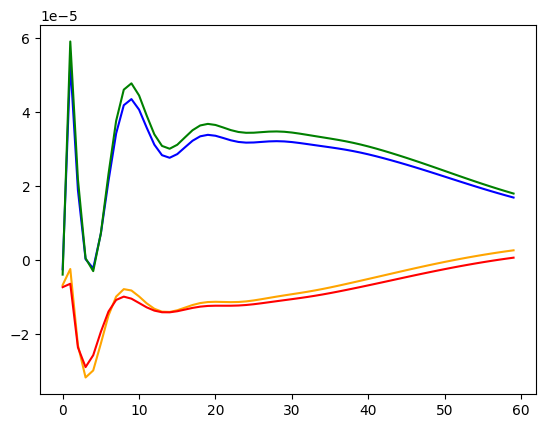

In [6]:
plt.plot(tracking_error[:60, 0], label='Tracking Error', color='blue')
plt.plot(tracking_error[:60, 1], label='Tracking Error', color='orange')
plt.plot(tracking_error[:60, 2], label='Tracking Error', color='green')
plt.plot(tracking_error[:60, 3], label='Tracking Error', color='red')

In [7]:
delta_pos = np.loadtxt("delta_pos_ada_120.csv", delimiter=',').reshape(-1, 8)
delta_pos_model = np.loadtxt("delta_pos_ada_pred_120.csv", delimiter=',').reshape(-1, 8)

tracking_error = delta_pos[1:] - delta_pos_model[1:]

tracking_error_norm = np.zeros((delta_pos.shape[0] - 1, 4))
for i in range(4):
    tracking_error_norm[:, i] = np.linalg.norm(tracking_error[:, i*2:(i+1)*2], axis=1)

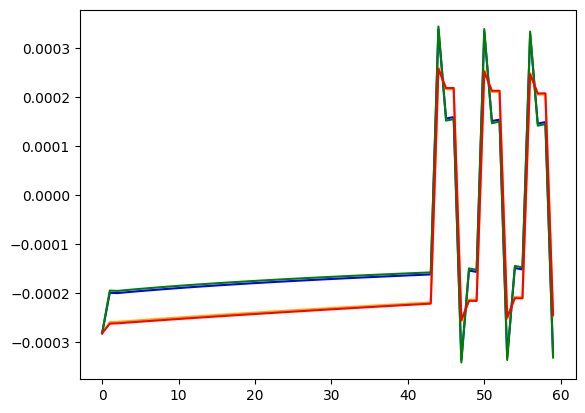

In [8]:
plt.plot(tracking_error[:60, 0], label='Tracking Error', color='blue')
plt.plot(tracking_error[:60, 1], label='Tracking Error', color='orange')
plt.plot(tracking_error[:60, 2], label='Tracking Error', color='green')
plt.plot(tracking_error[:60, 3], label='Tracking Error', color='red')